In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


In [2]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



In [127]:
#################### take each EC cell raw activity and min/max scale it then scale between 0 and 50 hz -- up to forst 58


def get_scaled_data_Hz_dict(activity_dict_EC, Hz_SF=50):
    scaled_data_Hz_dict={}
    for animal in activity_dict_EC:
        scaled_data_Hz_dict_cell = {}
        for cell in activity_dict_EC[animal]:
            activity = activity_dict_EC[animal][cell][:,:58]
            min_max_actiivty_list = []
            for i in range(activity.shape[1]):
                trial_activity = activity[:, i]
                min_max_actiivty = (trial_activity - (np.min(trial_activity))) / (np.max(trial_activity) - (np.min(trial_activity)))
                scaled_data_Hz = min_max_actiivty * Hz_SF
                min_max_actiivty_list.append(scaled_data_Hz)
            min_max_actiivty_array = np.array(min_max_actiivty_list)
            scaled_data_Hz_dict_cell[cell] = min_max_actiivty_array.T
        scaled_data_Hz_dict[animal] = scaled_data_Hz_dict_cell
    return scaled_data_Hz_dict

scaled_data_Hz_dict = get_scaled_data_Hz_dict(activity_dict_EC, Hz_SF=50)



In [ ]:

    
def do_the_interpolation(scaled_data_Hz_dict, an_velocity=None):
    
    padded_warped_activity_dict = {}

    dt_constant = 0.001

    for animal in scaled_data_Hz_dict:
        padded_cell = {}
        for cell in scaled_data_Hz_dict[animal]:

            summed_dendrite = scaled_data_Hz_dict[animal][cell]

            # if vel_applied == 'constant':
            #     an_velocity = np.full((summed_dendrite.shape), 0.43) #0.43 meters per second animal velocity 
            # else:
            an_velocity = an_velocity

            total_time_sec = 4.71657036 

            dt=total_time_sec/50
            dx=180/50

            proper_velocity=an_velocity*100

            animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

            # if vel_applied=="constant":
            #     dt = dx / animal_velocity_constant
            # else:
            dt = dx / proper_velocity

            time_bins = np.cumsum(dt, axis=0)
            time_bins_ms = time_bins * 1

            num_trials = summed_dendrite.shape[1]
            trial_warped_activity = []
            max_len = 0

            for t in range(num_trials):
                if np.any(np.isnan(time_bins[:, t])):
                    continue
                total_time = time_bins[-1, t]

                time_axis_constant = np.arange(0, total_time, dt_constant)
                
                firing = summed_dendrite[:, t]

                warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

                trial_warped_activity.append(warped_firing)
                if len(warped_firing) > max_len:
                    max_len = len(warped_firing)


            # if vel_applied=="constant":
            #     padded_warped_activity = np.full((num_trials, max_len), np.nan)
            #     for i, trace in enumerate(trial_warped_activity):
            #             padded_warped_activity[i, :len(trace)] = trace 

            #     padded_cell[cell] = padded_warped_activity
            # else:
            padded_cell[cell] = trial_warped_activity
        padded_warped_activity_dict[animal] = padded_cell

    return padded_warped_activity_dict, an_velocity



def get_inhom_poisson_spike_times_by_thinning(rate, t, dt=0.02, refractory=3., generator=None, rng=None):
    """
    Given a time series of instantaneous spike rates in Hz, produce a spike train consistent with an inhomogeneous
    Poisson process with a refractory period after each spike.
    :param rate: instantaneous rates in time (Hz)
    :param t: corresponding time values (ms)
    :param dt: temporal resolution for spike times (ms)
    :param refractory: absolute deadtime following a spike (ms)
    :param generator: :class:'random.Random()'
    :return: list of m spike times (ms)
    """
    if generator is None:
        generator = rng
    interp_t = np.arange(t[0], t[-1] + dt, dt)
    interp_rate = np.interp(interp_t, t, rate)
    interp_rate /= 1000.
    non_zero = np.where(interp_rate > 0.)[0]
    interp_rate[non_zero] = 1. / (1. / interp_rate[non_zero] - refractory)
    spike_times = []
    max_rate = np.max(interp_rate)
    i = 0
    ISI_memory = 0.
    while i < len(interp_t):
        x = generator.random()
        if x > 0.:
            ISI = -np.log(x) / max_rate
            i += int(ISI / dt)
            ISI_memory += ISI
            if (i < len(interp_t)) and (generator.random() <= interp_rate[i] / max_rate) and ISI_memory >= 0.:
                spike_times.append(interp_t[i])
                ISI_memory = -refractory
    return np.array(spike_times)

def exp_kernel(tau_ms, dt_ms, n_taus=5, norm="area", target=1.0):
    """
    Create a causal exponential kernel e^{-t/tau}.
    norm: "area" -> sum(kernel) == 1
          "peak" -> max(kernel) == 1
    target: scales the chosen normalization (e.g., target mV or arbitrary units).
    """
    klen = int(np.ceil(n_taus * tau_ms / dt_ms))
    t = np.arange(klen) * dt_ms
    k = np.exp(-t / tau_ms)

    if norm == "area":
        k /= k.sum() + 1e-12         # unit L1
    elif norm == "peak":
        k /= k.max() + 1e-12         # unit peak
    else:
        raise ValueError("norm must be 'area' or 'peak'")

    return k * target                # final amplitude per spike


def get_velocity_array(factors_dict_EC, factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest, which_type=None):

    if which_type == "EC_animal_average":
        an_velocity_real_list = []
        for animal in factors_dict_EC:
                an_velocity_real_list.append(factors_dict_EC[animal]["Velocity"][:,:58])

        an_velocity_real_array = np.array(an_velocity_real_list)
        an_velocity_real_array_mean_animal = np.mean(an_velocity_real_array, axis=0)
        return an_velocity_real_array_mean_animal
    
    elif which_type == "repeated_waveform":
        an_velocity_real_list_all = []
        for animal in factors_dict_EC:
                an_velocity_real_list_all.append(factors_dict_EC[animal]["Velocity"][:,:58])
        for animal in factors_dict_SST:
                an_velocity_real_list_all.append(factors_dict_SST[animal]["Velocity"][:,:58])
        for animal in fixed_filtered_factors_dict_NDNF_newest:
                an_velocity_real_list_all.append(fixed_filtered_factors_dict_NDNF_newest[animal]["Velocity"][:,:58])

        an_velocity_real_array_all = np.array(an_velocity_real_list_all)
        an_velocity_real_array_mean_animal_all = np.mean(an_velocity_real_array_all, axis=0)
        mean_velocity = np.mean(an_velocity_real_array_mean_animal_all, axis=1)
        mean_vel_2d = np.tile(mean_velocity[:,None], (1,58))
        return mean_vel_2d
    
    elif which_type == "constant":
         constant_vel = np.full((50,58), 0.43)
         return constant_vel

## which_type = repeated_waveform or EC_animal_average or constant 





(50, 58)
(4170,)


In [154]:
import pickle

file_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/epsp_spiking_model.pkl'
with open(file_path, 'wb') as f:
    pickle.dump(animal_dict, f)



In [506]:
### get the kernel 

def get_epsp_dict(padded_warped_activity_dict, tau_ms=None, amp=None, seed=None):

    dt_constant = 0.001

    dt_ms = dt_constant * 1000.0      # 1 ms

    tau_ms  = tau_ms
    dt_ms   = dt_constant * 1000.0      # 1 ms
    AMP     = amp                      # mV
    MODE    = "peak"                    # "area" or "peak"
    kernel  = exp_kernel(tau_ms, dt_ms, n_taus=5, norm=MODE, target=AMP)

    rng = np.random.default_rng(seed)


    animal_dict = {}
    for animal in padded_warped_activity_dict:
        cell_dict = {}
        for cell in padded_warped_activity_dict[animal]:
            epsps_dict= {}
            spike_times_dict = {}
            spike_train_dict = {}

            padded_warped_activity = padded_warped_activity_dict[animal][cell]

            for trial in range(len(padded_warped_activity)):
                
                example_padded_warped_activity = padded_warped_activity[trial]
                if trial > 0:
                    example_previous_pad = padded_warped_activity[trial-1]
                else:
                    example_previous_pad = padded_warped_activity[trial+1]

                L_prev = example_previous_pad.shape[0]
                L_curr = example_padded_warped_activity.shape[0]

                two_track_length = np.concatenate([example_previous_pad, example_padded_warped_activity], axis=0)
                t_ms = np.arange(two_track_length.shape[0]) * dt_ms

                spike_times = get_inhom_poisson_spike_times_by_thinning(two_track_length, t_ms, dt=dt_ms, refractory=3., generator=None, rng=rng).astype(int) 
                st_curr = spike_times[spike_times >= L_prev] - L_prev
                spike_times_dict[trial] = st_curr

                spike_train = np.zeros(two_track_length.shape, dtype=np.uint8)
                spike_train[spike_times] = 1
                spike_train_curr = spike_train[L_prev : L_prev + L_curr]
                spike_train_dict[trial] = spike_train_curr

                epsps = np.convolve(spike_train, kernel, mode='full')[:len(spike_train)]
                epsps_curr = epsps[L_prev : L_prev + L_curr]
                epsps_dict[trial] = epsps_curr
                # epsps_scaled = epsps-60
                # dendrite.append(epsps_scaled)
            


            cell_dict[cell] = {"epsps":epsps_dict,
                                "spike_times":spike_times_dict,
                                "spike_train":spike_train_dict}
        animal_dict[animal] = cell_dict

    return animal_dict, kernel

# def get_dend_vm(epsp_dict, Vrest=-60, epsp_sf = 0.1):

#     epsp_list = []
#     spike_list = []

#     for animal in epsp_dict:
#         for cell in epsp_dict[animal]:
#             epsp = epsp_dict[animal][cell]["epsps"]

#             max_len_epsp = max(len(epsp[trial]) for trial in epsp)

#             epsp_list_t = []
#             for trial in range(len(epsp)):
#                 epsp_trial = epsp[trial]
#                 if len(epsp_trial) < max_len_epsp:
#                     pad_width = max_len_epsp - len(epsp_trial)
#                     epsp_trial = np.pad(epsp_trial, (0, pad_width), 
#                                         constant_values=np.nan)
#                     epsp_list_t.append(epsp_trial)
#             epsp_array = np.array(epsp_list_t)
#             epsp_list.append(epsp_array)


#             spike_train = epsp_dict[animal][cell]["spike_train"]
#             max_len_spike_train = max(len(spike_train[trial]) for trial in spike_train)
#             spike_train_list = []
#             for trial in range(len(spike_train)):
#                 spike_trial = spike_train[trial]
#                 if len(spike_trial) < max_len_spike_train:
#                     pad_width = max_len_spike_train - len(spike_trial)
#                     spike_trial = np.pad(spike_trial, (0, pad_width), 
#                                         constant_values=np.nan)

#                     spike_train_list.append(spike_trial)
#             spike_train_array = np.array(spike_train_list)
#             spike_list.append(spike_train_array)

#     epsp_array = np.array(epsp_list)

#     sum_epsp = np.nansum(epsp_array, axis=0)

#     sum_epsp_centered = sum_epsp - np.nanmean(sum_epsp, axis=1, keepdims=True)

#     dend_Vm = Vrest + epsp_sf * sum_epsp_centered

#     return dend_Vm, epsp_list, spike_list



import numpy as np

def get_dend_vm(epsp_dict, Vrest=-60.0, epsp_sf=0.1):
    cell_epsp_mats = []
    cell_spike_mats = []

    # --- per cell: pad trials to that cell's max trial length ---
    for animal in epsp_dict:
        for cell in epsp_dict[animal]:
            epsp = epsp_dict[animal][cell]["epsps"]         # dict: trial -> 1D array
            spik = epsp_dict[animal][cell]["spike_train"]   # dict: trial -> 1D array

            # Per-cell max lengths
            max_len_epsp = max(len(epsp[t]) for t in epsp)
            max_len_spik = max(len(spik[t]) for t in spik)

            # EPSPs -> (n_trials, max_len_epsp)
            epsp_trials = []
            for t in range(len(epsp)):
                v = epsp[t]
                if len(v) < max_len_epsp:
                    v = np.pad(v, (0, max_len_epsp - len(v)), constant_values=np.nan)
                epsp_trials.append(v.astype(np.float32, copy=False))
            epsp_mat = np.vstack(epsp_trials)  # (n_trials, max_len_epsp)
            cell_epsp_mats.append(epsp_mat)

            # Spikes -> (n_trials, max_len_spik)
            spk_trials = []
            for t in range(len(spik)):
                v = spik[t]
                if len(v) < max_len_spik:
                    v = np.pad(v, (0, max_len_spik - len(v)), constant_values=np.nan)
                spk_trials.append(v.astype(np.float32, copy=False))
            spk_mat = np.vstack(spk_trials)
            cell_spike_mats.append(spk_mat)

    # --- across cells: pad to GLOBAL max length so we can stack cleanly ---
    # (trials can differ across cells; we’ll align by time axis length only)
    global_T = max(m.shape[1] for m in cell_epsp_mats)
    epsp_stack = []
    for m in cell_epsp_mats:
        if m.shape[1] < global_T:
            m = np.pad(m, ((0,0),(0, global_T - m.shape[1])), constant_values=np.nan)
        epsp_stack.append(m)
    # shape: (n_cells, n_trials, T) after stacking along a new axis
    epsp_stack = np.stack(epsp_stack, axis=0)

    # --- masked SUM across cells, keeping NaN where no data exists ---
    # count how many non-NaN cells contribute at each (trial, time) bin
    valid_counts = np.sum(~np.isnan(epsp_stack), axis=0)       # (n_trials, T)
    summed = np.nansum(epsp_stack, axis=0)                     # (n_trials, T)
    # where count == 0, set to NaN (instead of 0 from nansum)
    summed[valid_counts == 0] = np.nan

    # center per trial using nanmean (does not turn NaNs into zeros)
    trial_means = np.nanmean(summed, axis=1, keepdims=True)    # (n_trials, 1)
    summed_centered = summed - trial_means                     # (n_trials, T)

    # dendritic Vm (same shape)
    dend_Vm = Vrest + epsp_sf * summed_centered

    return dend_Vm, epsp_stack, cell_spike_mats




def plot_dend_vm_example(dend_Vm, epsp_list, spike_list, residual_activity_dict_EC, an_velocity):
    


    data_list = []
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            data_list.append(residual_activity_dict_EC[animal][cell][:,:58])

    data_array = np.array(data_list)
    summed_dendrite = np.sum(data_array, axis=0)

    padded_warped_activity_EC, summed_dendrite, an_velocity, just_plateau_starts_list, plateau_array, mean_dend_time, sem_dend_time, x_time_ms, just_plateau_starts_sums, cumulative_plateau_counts = get_internals_summed_dendrite(an_velocity, summed_dendrite, dt_constant=0.001, dend_threshold=-20, vel_applied="real")

    fig, axs= plt.subplots(2,2, figsize=(12,9))
    im = axs[0,0].imshow(padded_warped_activity_EC, aspect='auto')
    axs[0,0].set_title("Dendrite DF/F")
    axs[0,0].set_ylabel("Trials")
    axs[0,0].set_xlabel("Time (ms)")
    fig.colorbar(im, ax=axs[0,0], label="Z-Scored Summed DF/F")


    mean_padded_warped_activity_EC = np.nanmean(padded_warped_activity_EC, axis=0)
    sem_padded_warped_activity_EC = sem(padded_warped_activity_EC, axis=0, nan_policy='omit')

    axs[0,1].plot(mean_padded_warped_activity_EC)
    axs[0,1].fill_between(range(len(mean_padded_warped_activity_EC)), mean_padded_warped_activity_EC-sem_padded_warped_activity_EC, mean_padded_warped_activity_EC+sem_padded_warped_activity_EC, alpha=0.2)
    axs[0,1].set_title("Dendrite Trial Averaged DF/F")
    axs[0,1].set_xlabel("Time (ms)")
    axs[0,1].set_ylabel('Z-Scored Summed DF/F')



    fig.suptitle("Dend Vm from Summed Already Convolved EPSPs For Each EC Input")

    mean_dend = np.nanmean(dend_Vm, axis=0)
    sem_dend = sem(dend_Vm, axis=0, nan_policy='omit')

    axs[1,1].plot(mean_dend)
    axs[1,1].fill_between(range(len(mean_dend)), mean_dend+sem_dend, mean_dend-sem_dend, alpha=0.2)
    axs[1,1].axhline(Vrest, color='b', linestyle='--', label="Vrest")
    axs[1,1].legend()
    axs[1,1].set_title("Dendrite Vm")
    axs[1,1].set_ylabel("Vm (mV)")
    axs[1,1].set_xlabel("Time (ms)")

    im = axs[1,0].imshow(dend_Vm, aspect='auto')
    axs[1,0].set_title("Dendrite Vm")
    axs[1,0].set_ylabel("Trial")
    axs[1,0].set_xlabel("Time (ms)")
    fig.colorbar(im, ax=axs[1,0], label='Vm (mV)')

    plt.tight_layout()
    plt.plot()

    fig, axs = plt.subplots(1,2, figsize=(12,4))
    axs[0].plot(spike_list[0][0,3000:3300])
    axs[0].set_title("First Cell First Trial EC Turned into Spikes Using Poisson")
    axs[0].set_xlabel("Time (ms)")

    axs[1].plot(epsp_list[0][0,3000:3300])
    axs[1].set_title("First Cell First Trial EC Convolved Spikes")
    axs[1].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()

    def pad_sequences(seqs, pad_value=np.nan, dtype=float):
        """Pad 1D arrays in `seqs` to the same length."""
        seqs = [np.asarray(s, dtype=dtype) for s in seqs]
        maxlen = max(len(s) for s in seqs)
        out = np.full((len(seqs), maxlen), pad_value, dtype=dtype)
        for i, s in enumerate(seqs):
            out[i, :len(s)] = s
        return out


from scipy.ndimage import gaussian_filter1d


def plot_single_cell_trial_comparison(scaled_data_Hz_dict, padded_warped_activity_dict):
    fig, axs = plt.subplots(2,3, figsize=(16,8))

    first_ec_cell_rate_position = scaled_data_Hz_dict['animal_1']['cell_1']
    im = axs[0,0].imshow(first_ec_cell_rate_position.T, aspect='auto')
    axs[0,0].set_xlabel("Position Bins")
    axs[0,0].set_ylabel("Trials")
    axs[0,0].set_title("EC Cell 1 Rate Over Position")
    fig.colorbar(im, ax=axs[0,0], label="Hz")

    mean_dendrite = np.mean(first_ec_cell_rate_position, axis=1)
    sem_dendrite = sem(first_ec_cell_rate_position, axis=1)

    axs[1,0].plot(mean_dendrite)
    axs[1,0].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2)
    axs[1,0].set_title("Trial Averaged Dendrite Vm")
    axs[1,0].set_xlabel("Time (ms)")
    axs[1,0].set_ylabel("Mean Activity")

    first_ec_cell_rate_time = padded_warped_activity_dict['animal_1']['cell_1']
    max_len_padded = max(len(first_ec_cell_rate_time[t]) for t in range(len(first_ec_cell_rate_time)))
    padded_trials = []
    for t in range(len(first_ec_cell_rate_time)):
        v = first_ec_cell_rate_time[t]
        if len(v) < max_len_padded:
            v = np.pad(v, (0, max_len_padded - len(v)), constant_values=np.nan)
        padded_trials.append(v.astype(np.float32, copy=False))

    padded_trials_array = np.array(padded_trials)
    im = axs[0,1].imshow(padded_trials_array, aspect='auto', interpolation='none')
    axs[0,1].set_xlabel("Time (ms)")
    axs[0,1].set_ylabel("Trials")
    axs[0,1].set_title("EC Cell 1 Rate Over Time")
    fig.colorbar(im, ax=axs[0,1], label="Hz")

    mean_dendrite = np.mean(padded_trials_array, axis=0)
    sem_dendrite = sem(padded_trials_array, axis=0)

    axs[1,1].plot(mean_dendrite)
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2)
    axs[1,1].set_title("Trial Averaged Dendrite Vm")
    axs[1,1].set_xlabel("Time (ms)")
    axs[1,1].set_ylabel("Mean Activity")



    first_ec_cell_rate_time = padded_warped_activity_dict['animal_1']['cell_1']
    max_len_padded = max(len(first_ec_cell_rate_time[t]) for t in range(len(first_ec_cell_rate_time)))
    padded_trials = []
    for t in range(len(first_ec_cell_rate_time)):
        v = first_ec_cell_rate_time[t]
        if len(v) < max_len_padded:
            v = np.pad(v, (0, max_len_padded - len(v)), constant_values=np.nan)
        padded_trials.append(v.astype(np.float32, copy=False))



    spike_dict=epsp_dict['animal_1']['cell_1']["spike_train"]
    max_len_spike = max(len(spike_dict[t]) for t in range(len(spike_dict)))
    trial_list = []
    for t in range(len(spike_dict)):
        v = spike_dict[t]
        if len(v) < max_len_spike:
            v = np.pad(v, (0, max_len_spike - len(v)), constant_values=np.nan)
        trial_list.append(v.astype(np.float32, copy=False))
    trial_array = np.array(trial_list)
    im = axs[0,2].imshow(trial_array, aspect='auto')
    axs[0,2].set_xlabel("Time (ms)")
    axs[0,2].set_ylabel("Trials")
    axs[0,2].set_title("EC Cell 1 Spikes Over Time")
    axs[0,2].set_xlabel("Time (ms)")
    fig.colorbar(im, ax=axs[0,2])


    mean_dendrite = np.mean(trial_array, axis=0)
    sem_dendrite = sem(trial_array, axis=0)

    sigma = 10  # adjust this value depending on how much smoothing you want

    mean_dendrite_smooth = gaussian_filter1d(mean_dendrite, sigma=sigma)
    sem_dendrite_smooth = gaussian_filter1d(sem_dendrite, sigma=sigma)

    axs[1,2].plot(mean_dendrite_smooth)
    axs[1,2].fill_between(range(len(mean_dendrite_smooth)), mean_dendrite_smooth+sem_dendrite_smooth, mean_dendrite_smooth-sem_dendrite_smooth, alpha=0.2)
    axs[1,2].set_title("Smoothed Trial Averaged Dendrite Vm")
    axs[1,2].set_xlabel("Time (ms)")
    axs[1,2].set_ylabel("Mean Activity")

    plt.tight_layout()
    plt.plot()

    fig, axs = plt.subplots(2,1, figsize=(16,3))
    axs[0].plot(first_ec_cell_spikes[11,:])
    axs[0].set_title("Spikes Trial 11")
    axs[1].plot(first_ec_cell_rate_time[11], label="rate")
    axs[1].set_title("Rate Trial 11")
    axs[1].set_xlabel("Time (ms)")

    plt.tight_layout()
    plt.show()


In [440]:
def get_internals_summed_dendrite(an_velocity, summed_dendrite, dt_constant=0.001, dend_threshold=None, vel_applied=None):


    animal_velocity_constant = np.full((summed_dendrite.shape), 23)
    total_time_sec = 4.71657036 

    dt=total_time_sec/50
    dx=180/50

    proper_velocity=an_velocity*100

    animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

    if vel_applied=="constant":
        dt = dx / animal_velocity_constant
    else:
        dt = dx / proper_velocity

    time_bins = np.cumsum(dt, axis=0)
    time_bins_ms = time_bins * 1

    num_trials = summed_dendrite.shape[1]
    trial_warped_activity = []
    max_len = 0

    for t in range(num_trials):
        if np.any(np.isnan(time_bins[:, t])):
            continue
        total_time = time_bins[-1, t]

        time_axis_constant = np.arange(0, total_time, dt_constant)
        
        firing = summed_dendrite[:, t]

        warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

        trial_warped_activity.append(warped_firing)
        if len(warped_firing) > max_len:
            max_len = len(warped_firing)
                
    padded_warped_activity = np.full((num_trials, max_len), np.nan) 
    for i, trace in enumerate(trial_warped_activity):
        padded_warped_activity[i, :len(trace)] = trace

        
        
    mean_dend_time = np.mean(padded_warped_activity, axis=0)
    sem_dend_time = sem(padded_warped_activity, axis=0)


    x_start = 0
    time_bin_size_ms=1
    num_bins = len(mean_dend_time)
    x_end = num_bins * time_bin_size_ms 


    time_bin_size_ms = 1

    num_bins = len(mean_dend_time)
    x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms


    position_bins, num_trials = animal_velocity_constant.shape


    flat_padded_warped_activity = padded_warped_activity.flatten()
    flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

    just_plateau_starts = np.zeros_like(flat_padded_warped_activity)
    just_plateau_starts_list = []
    i = 0
    while i < len(flat_padded_warped_activity):
        if flat_padded_warped_activity[i] > dend_threshold:
            flat_plateau_array[i:i+300] = 1
            just_plateau_starts[i] = 1
            just_plateau_starts_list.append(i)
            
            i += 800
        else:
            i += 100


    plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

    just_plateau_starts_reshape = just_plateau_starts.reshape(padded_warped_activity.shape)

    just_plateau_starts_sums = np.sum(just_plateau_starts_reshape, axis=1)

    # Compute the cumulative sum of plateaus across trials
    cumulative_plateau_counts = np.cumsum(just_plateau_starts_sums)


    return padded_warped_activity, summed_dendrite, an_velocity, just_plateau_starts_list, plateau_array, mean_dend_time, sem_dend_time, x_time_ms, just_plateau_starts_sums, cumulative_plateau_counts


In [512]:
an_velocity = get_velocity_array(factors_dict_EC, factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest, which_type="constant") #repeated_waveform # EC_animal_average #constant

padded_warped_activity_dict, an_velocity = do_the_interpolation(scaled_data_Hz_dict, an_velocity=an_velocity)

epsp_dict, kernel = get_epsp_dict(padded_warped_activity_dict, tau_ms=5.0, amp=1., seed=None)

dend_Vm, epsp_list, spike_list = get_dend_vm(epsp_dict, Vrest=-60, epsp_sf = 0.1)


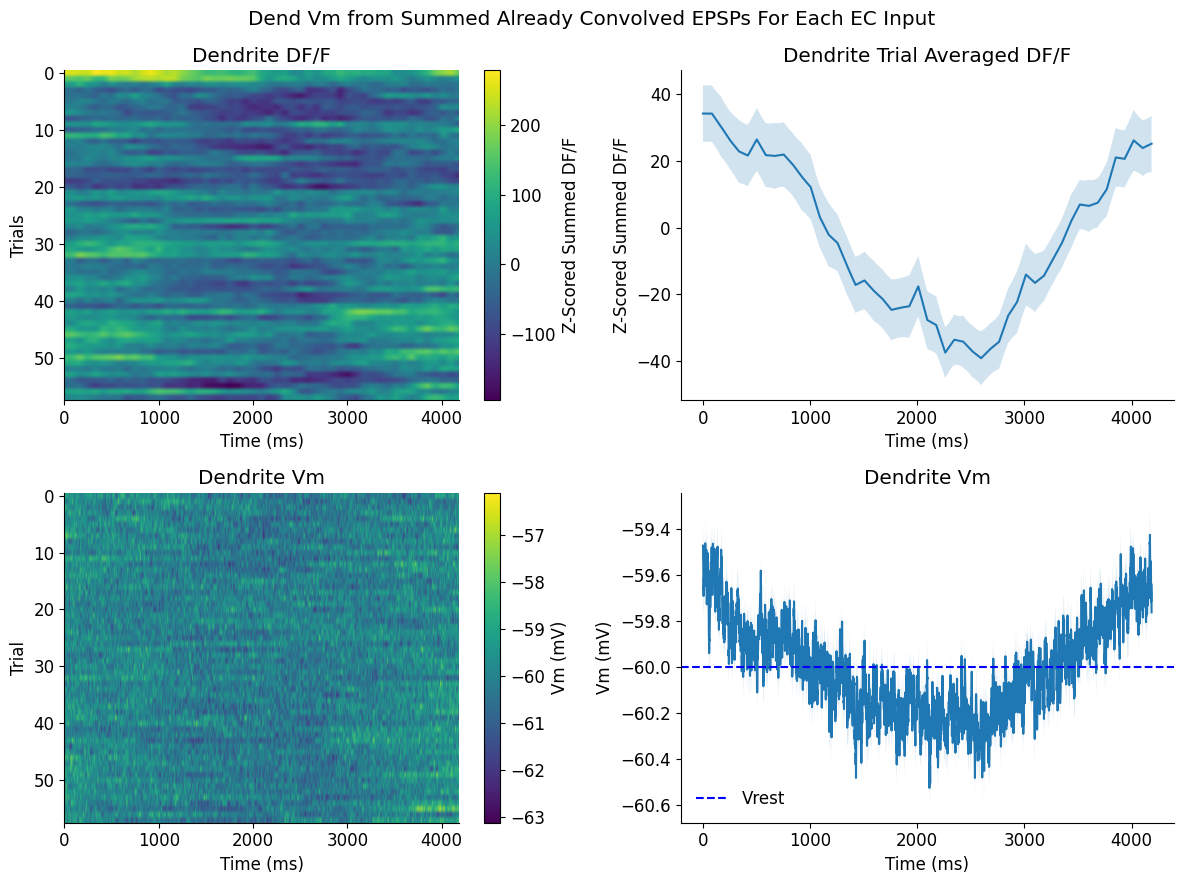

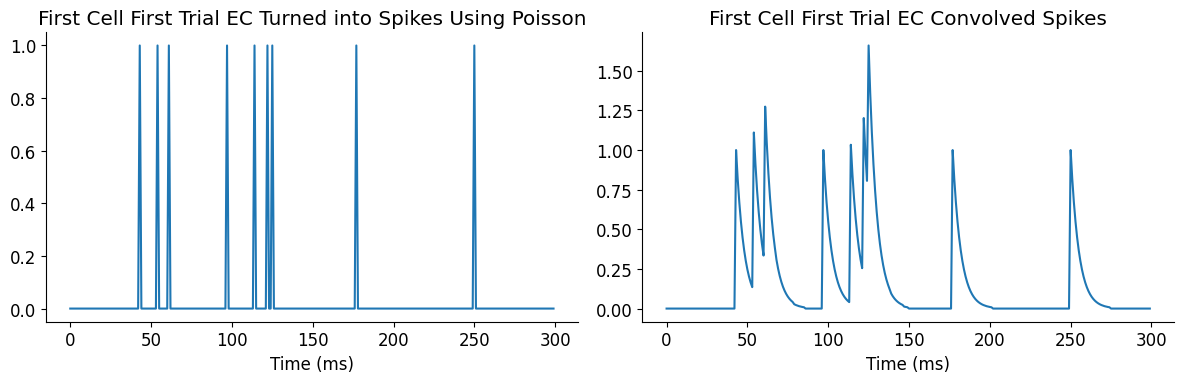

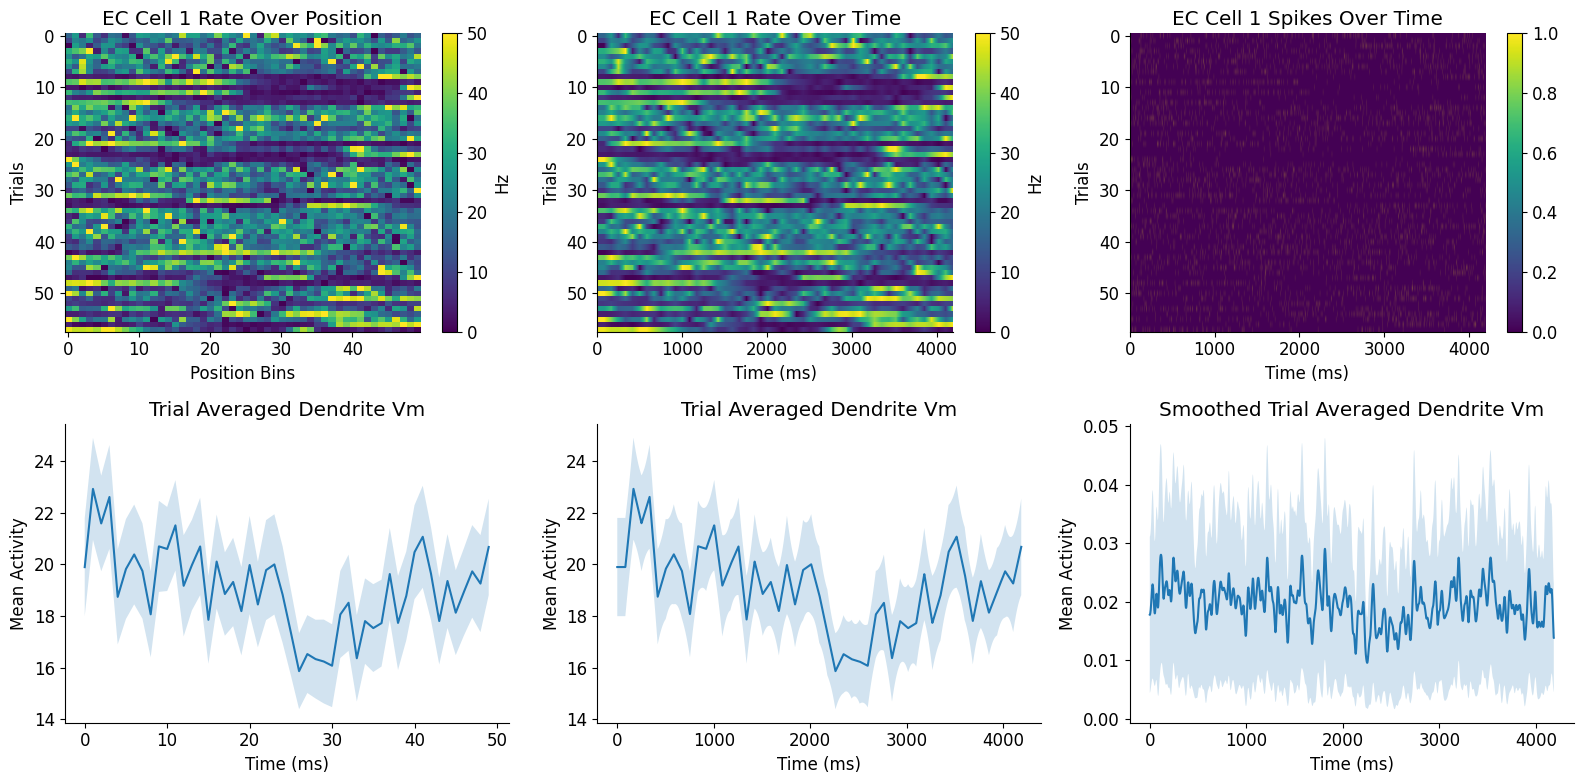

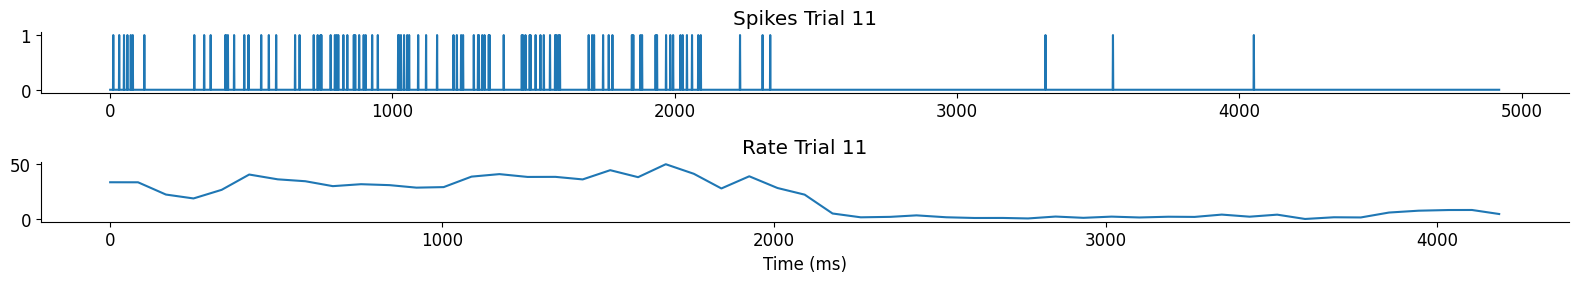

In [514]:
plot_dend_vm_example(dend_Vm, epsp_list, spike_list, activity_dict_EC, an_velocity)
plot_single_cell_trial_comparison(scaled_data_Hz_dict, padded_warped_activity_dict)

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_20602/3259853306.py:87: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_padded_warped_activity_EC = sem(padded_warped_activity_EC, axis=0, nan_policy='omit')
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_20602/3259853306.py:106: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_dendrite = sem(dend_Vm, axis=0, nan_policy='omit')
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_20602/3259853306.py:116: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See do

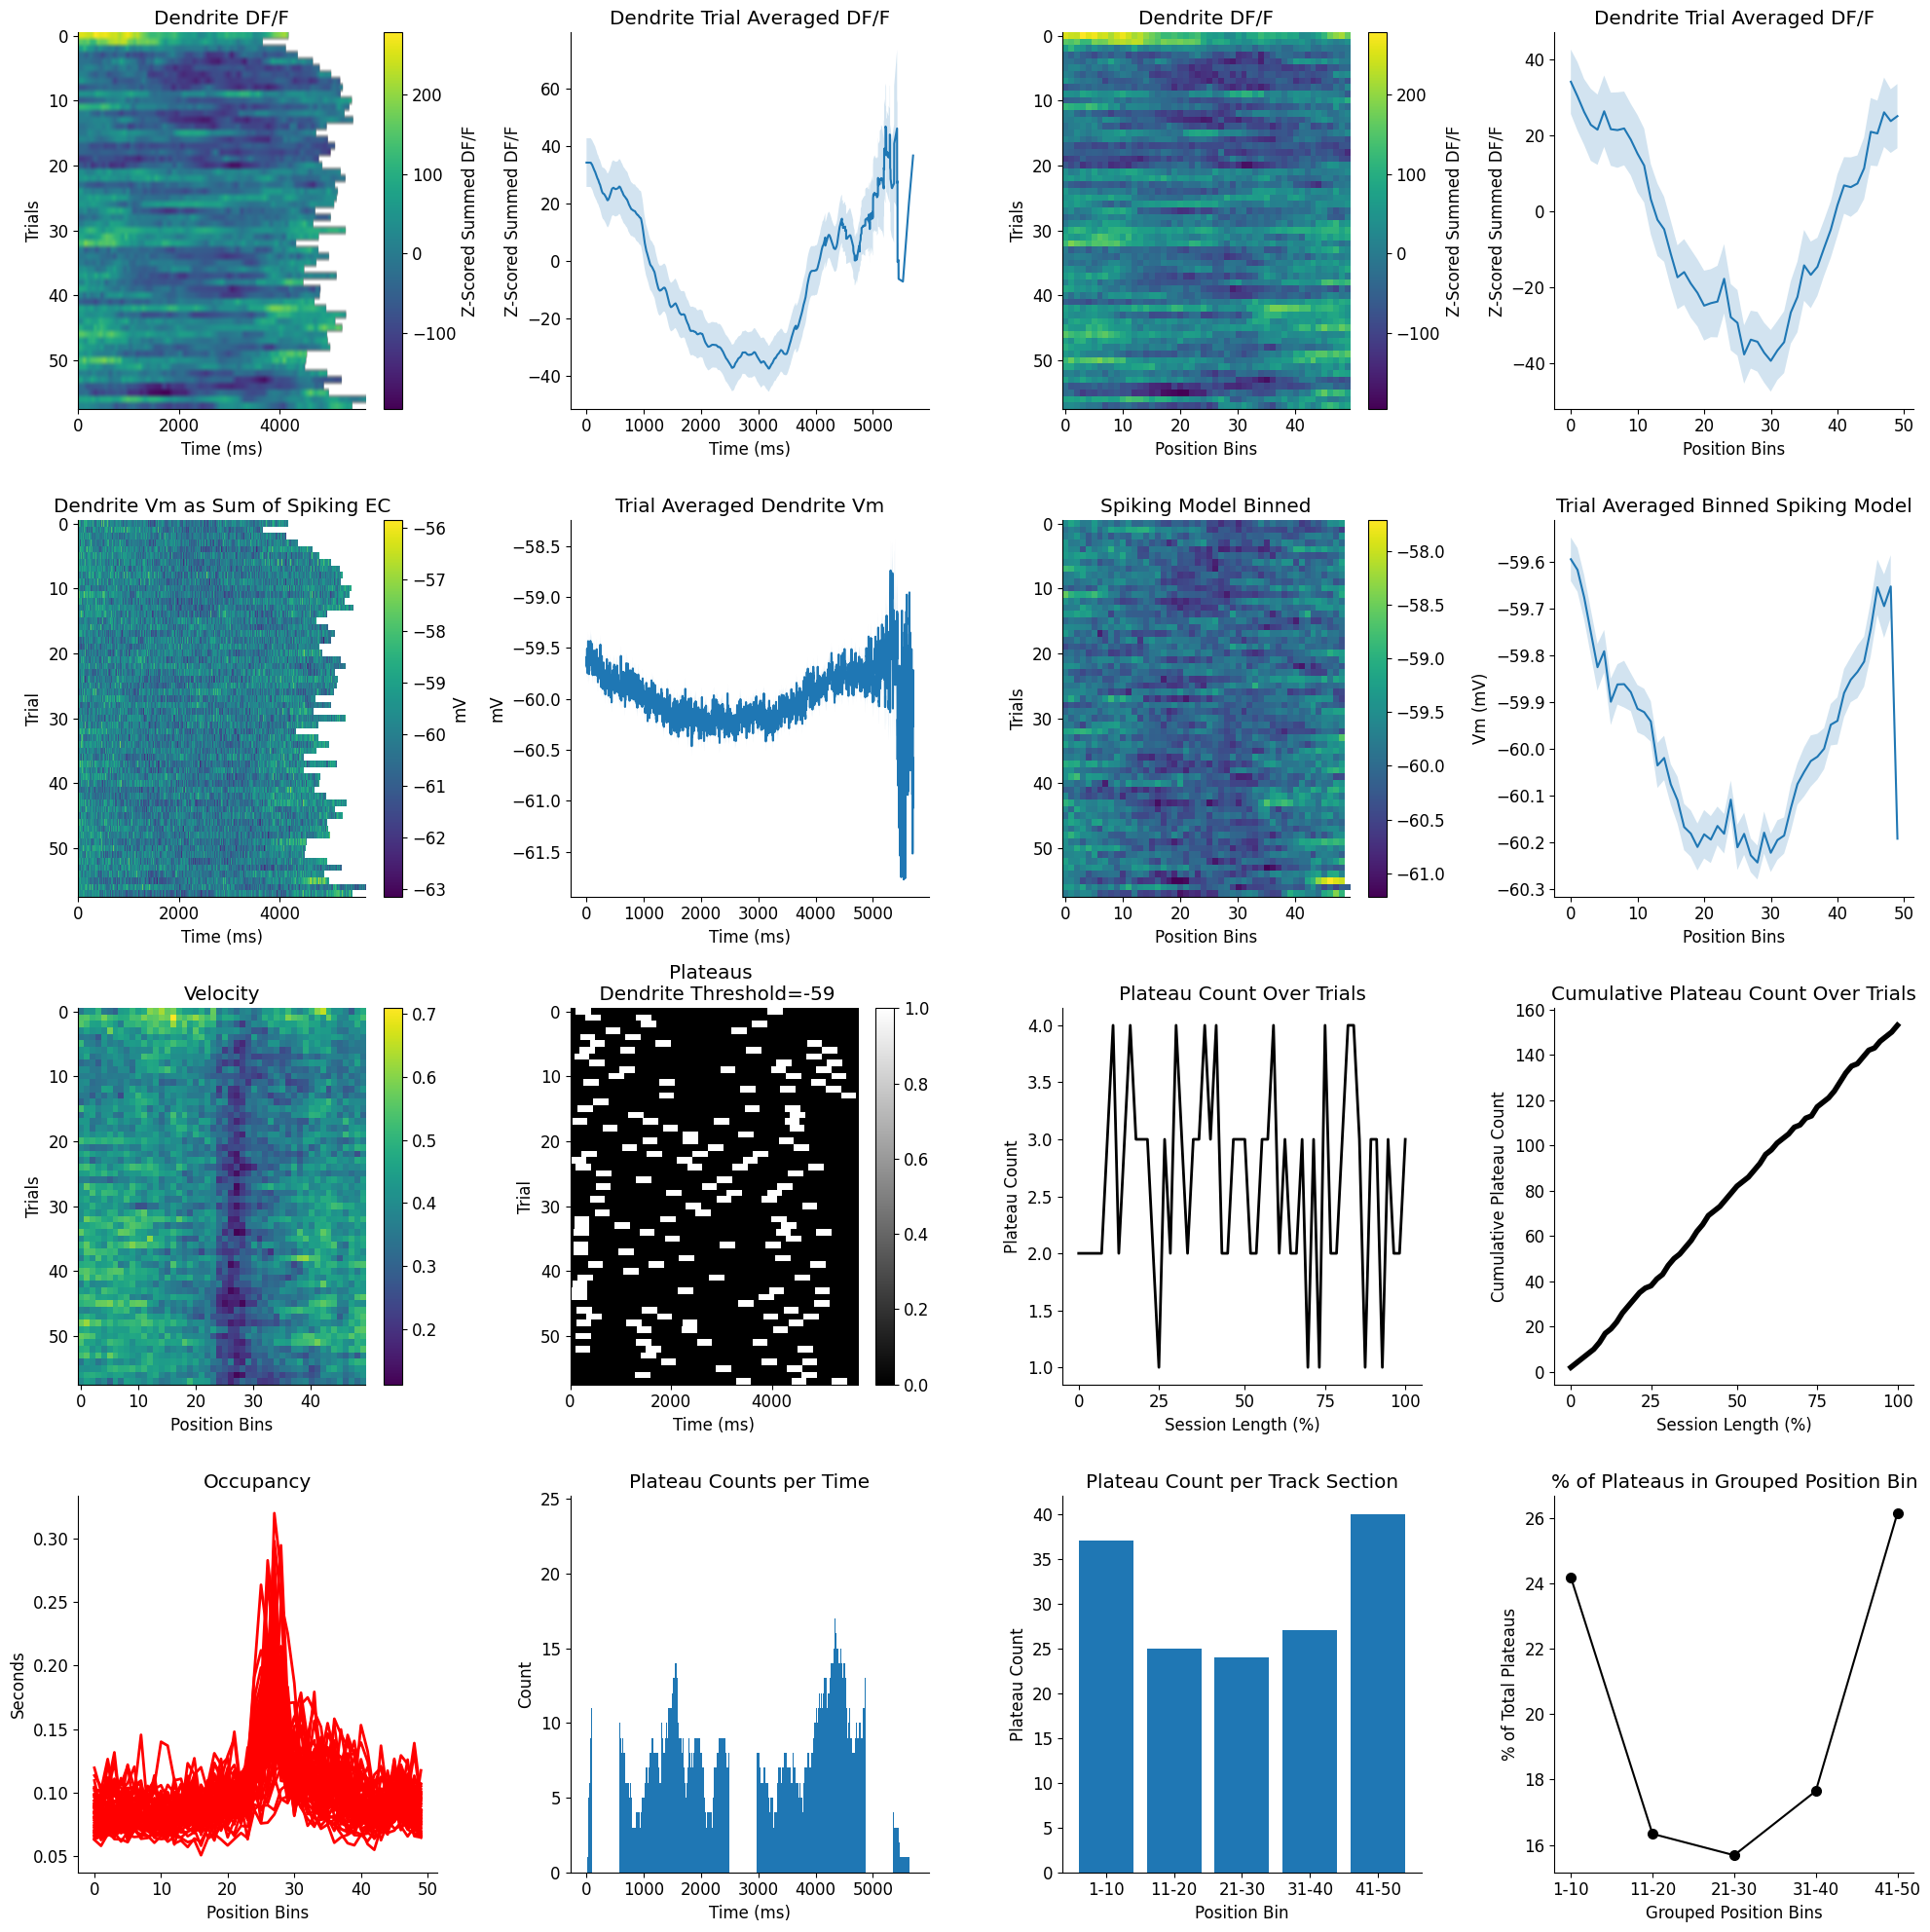

In [509]:
# dend_Vm_one_trial = dend_Vm_one_trial[0,:]


# print(dend_Vm_one_trial.shape)

#mV




def get_plateau_array(dend_Vm, dend_threshold=None):
    x_start = 0
    time_bin_size_ms=1
    num_bins = dend_Vm.shape[1]
    x_end = num_bins * time_bin_size_ms 
    time_bin_size_ms = 1

    x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms

    flat_padded_warped_activity = dend_Vm.flatten()
    flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

    just_plateau_starts = np.zeros_like(flat_padded_warped_activity)
    just_plateau_starts_list = []
    i = 0
    while i < len(flat_padded_warped_activity):
        if flat_padded_warped_activity[i] > dend_threshold:
            flat_plateau_array[i:i+300] = 1
            just_plateau_starts[i] = 1
            just_plateau_starts_list.append(i)
            
            i += 800
        else:
            i += 100


    plateau_array = flat_plateau_array.reshape(dend_Vm.shape)

    just_plateau_starts_reshape = just_plateau_starts.reshape(dend_Vm.shape)

    just_plateau_starts_sums = np.sum(just_plateau_starts_reshape, axis=1)

    return just_plateau_starts_sums, plateau_array




def plot_dendrite_spikes(dend_Vm, an_velocity, residual_activity_dict_EC, dend_threshold=None):

    fig, axs = plt.subplots(4,4, figsize=(20,20))


    data_list = []
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            data_list.append(residual_activity_dict_EC[animal][cell][:,:58])

    data_array = np.array(data_list)
    summed_dendrite = np.sum(data_array, axis=0)

    im = axs[0,2].imshow(summed_dendrite.T, aspect='auto')
    axs[0,2].set_title("Dendrite DF/F")
    axs[0,2].set_ylabel("Trials")
    axs[0,2].set_xlabel("Position Bins")
    fig.colorbar(im, ax=axs[0,2], label="Z-Scored Summed DF/F")

    mean_summed_dend = np.mean(summed_dendrite, axis=1)
    sem_summed_dend = sem(summed_dendrite, axis=1, nan_policy='omit')

    axs[0,3].plot(mean_summed_dend)
    axs[0,3].fill_between(range(len(mean_summed_dend)), mean_summed_dend-sem_summed_dend, mean_summed_dend+sem_summed_dend, alpha=0.2)
    axs[0,3].set_title("Dendrite Trial Averaged DF/F")
    axs[0,3].set_xlabel("Position Bins")
    axs[0,3].set_ylabel('Z-Scored Summed DF/F')


    padded_warped_activity_EC, summed_dendrite, an_velocity, just_plateau_starts_list, plateau_array, mean_dend_time, sem_dend_time, x_time_ms, just_plateau_starts_sums, cumulative_plateau_counts = get_internals_summed_dendrite(an_velocity, summed_dendrite, dt_constant=0.001, dend_threshold=dend_threshold, vel_applied="real")

    im = axs[0,0].imshow(padded_warped_activity_EC, aspect='auto')
    axs[0,0].set_title("Dendrite DF/F")
    axs[0,0].set_ylabel("Trials")
    axs[0,0].set_xlabel("Time (ms)")
    fig.colorbar(im, ax=axs[0,0], label="Z-Scored Summed DF/F")


    mean_padded_warped_activity_EC = np.nanmean(padded_warped_activity_EC, axis=0)
    sem_padded_warped_activity_EC = sem(padded_warped_activity_EC, axis=0, nan_policy='omit')

    axs[0,1].plot(mean_padded_warped_activity_EC)
    axs[0,1].fill_between(range(len(mean_padded_warped_activity_EC)), mean_padded_warped_activity_EC-sem_padded_warped_activity_EC, mean_padded_warped_activity_EC+sem_padded_warped_activity_EC, alpha=0.2)
    axs[0,1].set_title("Dendrite Trial Averaged DF/F")
    axs[0,1].set_xlabel("Time (ms)")
    axs[0,1].set_ylabel('Z-Scored Summed DF/F')





    im=axs[1,0].imshow(dend_Vm, aspect='auto', interpolation='none')
    axs[1,0].set_ylabel("Trial")
    axs[1,0].set_xlabel("Time (ms)")
    axs[1,0].set_title("Dendrite Vm as Sum of Spiking EC")
    fig.colorbar(im, ax=axs[1,0], label="mV")

    mean_dendrite = np.nanmean(dend_Vm, axis=0)
    sem_dendrite = sem(dend_Vm, axis=0, nan_policy='omit')

    axs[1,1].plot(mean_dendrite)
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2)
    axs[1,1].set_title("Trial Averaged Dendrite Vm")
    axs[1,1].set_xlabel("Time (ms)")
    axs[1,1].set_ylabel("mV")

    centers_cm, Vm_binned, occ_ms = bin_vm_time_to_position(dend_Vm, dt_ms=1.0, vel_pos_trial_m_s=an_velocity)
    Vm_mean_across_trials = np.nanmean(Vm_binned, axis=0) 
    Vm_sem_across_trials = sem(Vm_binned, axis=0, nan_policy='omit') 

    im = axs[1,2].imshow(Vm_binned, aspect='auto')
    axs[1,2].set_ylabel("Trials")
    axs[1,2].set_xlabel("Position Bins")
    axs[1,2].set_title("Spiking Model Binned")
    fig.colorbar(im, ax=axs[1,2])

    axs[1,3].plot(Vm_mean_across_trials)
    axs[1,3].fill_between(range(len(Vm_mean_across_trials)), Vm_mean_across_trials+Vm_sem_across_trials, Vm_mean_across_trials-Vm_sem_across_trials, alpha=0.2)
    axs[1,3].set_ylabel("Vm (mV)")
    axs[1,3].set_xlabel("Position Bins")
    axs[1,3].set_title("Trial Averaged Binned Spiking Model")

    im = axs[2,0].imshow(an_velocity.T, aspect='auto')
    axs[2,0].set_title("Velocity")
    axs[2,0].set_xlabel("Position Bins")
    axs[2,0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])


    total_track_length=1.8 #meters
    num_pos_bins=50
    dist_per_pos_bin = total_track_length / num_pos_bins
    occupancy = dist_per_pos_bin/an_velocity

    axs[3,0].plot(occupancy, color='r', linewidth=2)
    axs[3,0].set_title("Occupancy")
    axs[3,0].set_xlabel("Position Bins")
    axs[3,0].set_ylabel("Seconds")

    



    


    just_plateau_starts_sums, plateau_array = get_plateau_array(dend_Vm, dend_threshold)


    im = axs[2,1].imshow(plateau_array, aspect='auto', interpolation='none', cmap='grey')
    axs[2,1].set_title(f"Plateaus \n Dendrite Threshold={dend_threshold}")
    axs[2,1].set_ylabel("Trial")
    axs[2,1].set_xlabel("Time (ms)")
    fig.colorbar(im, ax=axs[2,1])

    axs[2,2].plot(just_plateau_starts_sums, color='k', linewidth=2)
    axs[2,2].set_title("Plateau Count Over Trials")
    axs[2,2].set_ylabel("Plateau Count")
    axs[2,2].set_xlabel("Session Length (%)")
    axs[2,2].set_xticks([0, len(just_plateau_starts_sums)//4, len(just_plateau_starts_sums)//2, len(just_plateau_starts_sums)//4+len(just_plateau_starts_sums)//2,len(just_plateau_starts_sums) - 1], labels=["0", "25", "50", "75", "100"])


    cumulative_plateau_counts = np.cumsum(just_plateau_starts_sums)
    axs[2,3].plot(cumulative_plateau_counts, color='k', linewidth=4)
    axs[2,3].set_title("Cumulative Plateau Count Over Trials")
    axs[2,3].set_ylabel("Cumulative Plateau Count")
    axs[2,3].set_xlabel("Session Length (%)")
    axs[2,3].set_xticks([0, len(cumulative_plateau_counts)//4, len(cumulative_plateau_counts)//2, len(cumulative_plateau_counts)//4 + len(cumulative_plateau_counts)//2, len(cumulative_plateau_counts) - 1], 
                        labels=["0", '25', "50", '75', "100"])



    track_len_cm = 180.0
    n_pos = an_velocity.shape[0]    

    dx = track_len_cm / n_pos       

    dt_constant = 1.0 / 1000.0  

    starts_per_pos, time_per_pos_s, plateau_start_positions_counter = get_internal_counts(an_velocity, plateau_array, dx=dx, dt_constant=dt_constant)

    n_bins = 5
    bin_size = int(50 / n_bins)

    summed_plateaus = np.zeros(n_bins)

    for i in range(n_bins):
        start = i * bin_size
        end = (i + 1) * bin_size
        summed_data = np.sum(plateau_start_positions_counter[start:end])
        summed_plateaus[i] = summed_data

    plateau_counts_per_time = np.sum(plateau_array, axis=0)
    axs[3,1].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
    axs[3,1].set_xlabel("Time (ms)")
    axs[3,1].set_ylabel("Count")
    axs[3,1].set_title("Plateau Counts per Time")


    axs[3,2].bar(range(len(summed_plateaus)), summed_plateaus)
    axs[3,2].set_xlabel("Position Bin")
    axs[3,2].set_ylabel("Plateau Count")
    axs[3,2].set_title("Plateau Count per Track Section")
    axs[3,2].set_xticks(np.arange(n_bins), ["1-10", "11-20", "21-30", "31-40", "41-50"])

    total_plateaus = np.sum(summed_plateaus)
    fraction_plateaus = summed_plateaus / total_plateaus
    axs[3,3].plot(fraction_plateaus*100, marker='o', color='k', markersize=7)
    axs[3,3].set_title("% of Plateaus in Grouped Position Bin")
    axs[3,3].set_xlabel("Grouped Position Bins")
    axs[3,3].set_ylabel("% of Total Plateaus")
    axs[3,3].set_xticks(np.arange(5), ["1-10", "11-20", "21-30", "31-40", "41-50"])


    plt.tight_layout()
    plt.show()




plot_dendrite_spikes(dend_Vm, an_velocity, activity_dict_EC, dend_threshold=-59)




In [284]:

def get_internal_counts(an_velocity, plateau_array, dx=None, dt_constant=None):
    
    plateau_start_positions_counter = np.zeros(50)

    n_trials, n_time = plateau_array.shape
    n_pos = 50


    vel_cm_s = an_velocity * 100.0  # (50, n_trials)

    plateau_time_per_pos_s   = np.zeros(n_pos, dtype=float)  # duration in seconds
    plateau_starts_per_pos   = np.zeros(n_pos, dtype=int)    # onset counts

    # time axis for the (max) warped length
    time_axis = np.arange(n_time) * dt_constant  # seconds

    for t in range(n_trials):
        v = vel_cm_s[:, t].astype(float)  # (50,)
        
        dt_trial = dx / v   #time spent in each position bin
        edges = np.concatenate([[0.0], np.cumsum(dt_trial)])  #cumulative edges in time 
        total_T  = edges[-1]

        # --- get mask for this trial
        valid_mask = time_axis < total_T
        if not np.any(valid_mask):
            continue

        pos_idx_for_time = np.searchsorted(edges, time_axis[valid_mask], side='right') - 1 #map the time sample onto position bins
        pos_idx_for_time = np.clip(pos_idx_for_time, 0, n_pos-1)

        # weight by dt to convert samples → seconds
        plateau_mask = plateau_array[t, valid_mask].astype(bool)
        w = plateau_mask.astype(float) * dt_constant  # seconds
        add_s = np.bincount(pos_idx_for_time, weights=w, minlength=n_pos)
        plateau_time_per_pos_s += add_s

        # --- COUNT OF PLATEAU STARTS per pos-bin (onsets)
        row = plateau_array[t, :np.count_nonzero(valid_mask)]  # truncate to trial time
        starts_idx = np.flatnonzero((np.pad(row.astype(int), (1,0))[:-1] == 0) &
                                    (np.pad(row.astype(int), (1,0))[1:]  == 1))
        if starts_idx.size:
            start_times = starts_idx * dt_constant
            pos_of_starts = np.searchsorted(edges, start_times, side='right') - 1
            pos_of_starts = np.clip(pos_of_starts, 0, n_pos-1)
            np.add.at(plateau_starts_per_pos, pos_of_starts, 1)

    for trial in range(plateau_array.shape[0]):
        velocity_trial = an_velocity[:, trial] *100.0
#         velocity_trial = proper_velocity
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        plateau_start_indices = np.where(np.diff(np.pad(plateau_array[trial], (1, 0))) == 1)[0]
        plateau_start_times = plateau_start_indices * dt_constant  # in seconds
        # plateau_start_times_list.append(plateau_start_times)

        for pt_start_time in plateau_start_times:
            if pt_start_time != 0.0:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= pt_start_time < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_start_positions_counter[pos_idx] += 1
                        break

    return plateau_starts_per_pos, plateau_time_per_pos_s, plateau_start_positions_counter



In [ ]:
do_the_interpolation(scaled_data_Hz_dict, factors_dict_EC, vel_applied='constant')

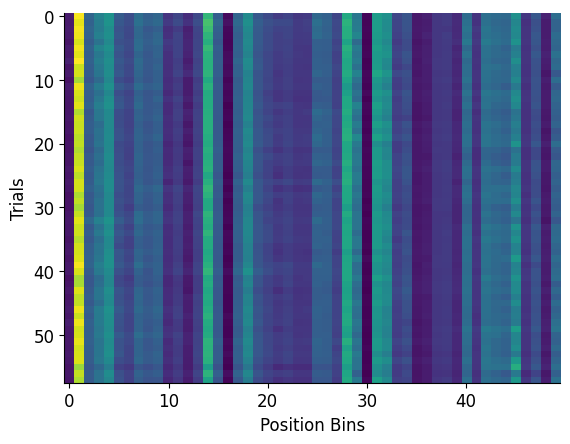

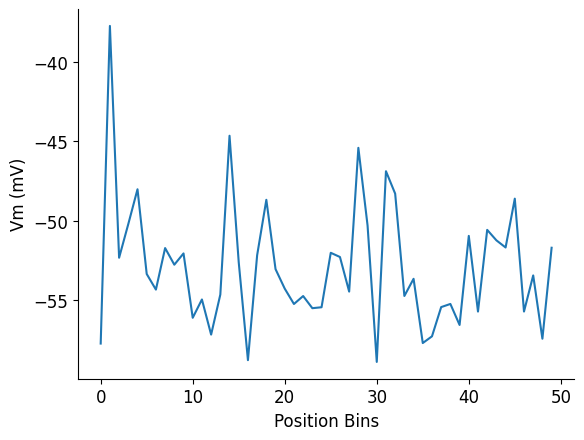

In [269]:
import numpy as np

def bin_vm_time_to_position(Vm_trials, dt_ms, vel_pos_trial_m_s, track_len_cm=180.0):
    """
    Map Vm(t) per trial to position bins using position-dependent velocity.
    Returns:
      centers_cm: (n_pos,)
      Vm_binned:  (n_trials, n_pos) time-weighted mean Vm per bin
      occ_ms:     (n_trials, n_pos) time spent in each position bin (ms)
    """
    n_trials, T = Vm_trials.shape
    n_pos, n_trials_v = vel_pos_trial_m_s.shape
    assert n_trials == n_trials_v, "Trials mismatch between Vm and velocity arrays."

    # bin geometry
    bin_edges_cm  = np.linspace(0.0, track_len_cm, n_pos + 1)           # (n_pos+1,)
    centers_cm    = 0.5 * (bin_edges_cm[:-1] + bin_edges_cm[1:])        # (n_pos,)
    bin_width_cm  = track_len_cm / n_pos

    # precompute sample times for one trial
    t_ms = np.arange(T, dtype=float) * dt_ms                             # (T,)

    Vm_binned = np.full((n_trials, n_pos), np.nan, dtype=float)
    occ_ms    = np.zeros((n_trials, n_pos), dtype=float)

    for tr in range(n_trials):
        # velocity per position bin for this trial → cm/s
        v_cm_s = np.asarray(vel_pos_trial_m_s[:, tr], dtype=float) * 100.0
        # guard against zeros
        v_cm_s = np.maximum(v_cm_s, 1e-6)

        # time spent in each position bin (ms): Δt = Δx / v
        # Δx = bin_width_cm; v in cm/s → ms: multiply by 1000
        dt_per_bin_ms = (bin_width_cm / v_cm_s) * 1000.0                 # (n_pos,)

        # cumulative time edges for the lap in ms
        edges_ms = np.concatenate(([0.0], np.cumsum(dt_per_bin_ms)))     # (n_pos+1,)

        # map each time sample to a position bin via cumulative time
        # bin index k such that edges_ms[k] <= t < edges_ms[k+1]
        bin_idx = np.searchsorted(edges_ms, t_ms, side="right") - 1      # (T,)
        # clip to valid range
        bin_idx = np.clip(bin_idx, 0, n_pos - 1)

        # time-weighted accumulation: each sample contributes dt_ms to its bin
        vm = Vm_trials[tr]                                               # (T,)
        vm_sum = np.zeros(n_pos, dtype=float)
        occ   = np.zeros(n_pos, dtype=float)

        np.add.at(vm_sum, bin_idx, vm * dt_ms)   # accumulate Vm * Δt
        np.add.at(occ,    bin_idx, dt_ms)        # accumulate Δt

        # compute time-weighted mean
        with np.errstate(invalid="ignore", divide="ignore"):
            vm_mean = vm_sum / occ
        Vm_binned[tr] = vm_mean
        occ_ms[tr]    = occ

    return centers_cm, Vm_binned, occ_ms

# --------- example usage ---------
# an_velocity: (n_pos=50, n_trials=58)
# dend_Vm:     (n_trials=58, T)   <-- your time traces per trial
# dt_ms:       set to your actual bin width (e.g., 1.0)

centers_cm, Vm_binned, occ_ms = bin_vm_time_to_position(dend_Vm, dt_ms=1.0, vel_pos_trial_m_s=mean_vel_2d)
Vm_mean_across_trials = np.nanmean(Vm_binned, axis=0)  # (n_pos,)

plt.imshow(Vm_binned, aspect='auto')
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.imshow(Vm_binned, aspect='auto')
plt.show()
plt.plot(Vm_mean_across_trials)
plt.ylabel("Vm (mV)")
plt.xlabel("Position Bins")
plt.show()


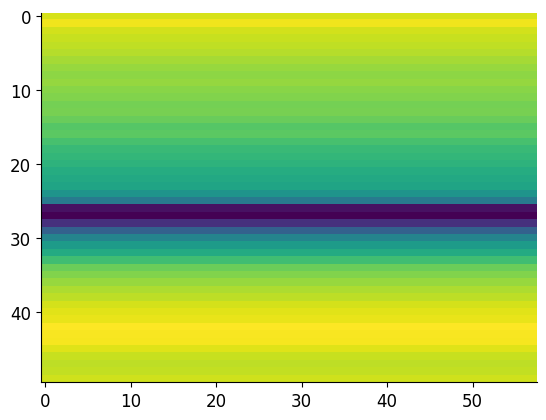

In [ ]:


def plot_the_dendrite(dend_Vm, an_velocity, mean_new_average_vel_array, NDNF_contribution_sum, SST_contribution_sum, dend_threshold=20, vel_applied=None, include_inhibition="both", ylim=None, pad_with_means=True):

    dx = 180/50 #track len (cm) / num pos bins

    summed_dendrite = dend_contribution_EC

    fig, axs = plt.subplots(4,3, figsize=(20, 25))  
    # plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals=False, velocity modulation={vel_applied}")
    
    EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

    mean_EC_dend = np.mean(EC_normalized, axis=1)
    sem_EC_dend = sem(EC_normalized, axis=1)
    axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
    axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
    axs[0,0].set_title(f"Mean EC Dend Contribution SF={1.0}")
    axs[0,0].set_xlabel("Position Bin")
    axs[0,0].set_ylabel("Activity")
    axs[0,0].set_ylim(0,1)

    im = axs[0,1].imshow(an_velocity.T, aspect='auto')
    axs[0,1].set_title("Average Animal Velocity")
    axs[0,1].set_ylabel("Trials")
    axs[0,1].set_xlabel("Position Bin")
    fig.colorbar(im, ax=axs[0,1], label="Meters/Second")
    

    vel_cm_sec = np.mean(an_velocity, axis=1)*100
    distance = dx
    axs[0,2].plot(distance/vel_cm_sec, color='r', linewidth=2)
    axs[0,2].set_ylabel("Seconds")
    axs[0,2].set_xlabel("Position Bins")
    axs[0,2].set_title("Average Animal Occupancy")
    
    
    summed_dendrite = zscore_2d(summed_dendrite, axis=None, eps=1e-12)

    im11 = axs[1,0].imshow(dend_Vm, aspect='auto')
    axs[1,0].set_title("Dendrite Over Time")
    axs[1,0].set_xlabel("Time (ms)")
    axs[1,0].set_ylabel("Trials")
    fig.colorbar(im11, ax=axs[1,0])

    mean_dendrite = np.mean(summed_dendrite, axis=1)
    sem_dendrite = sem(summed_dendrite, axis=1)

    axs[1,1].plot(mean_dendrite, color='k')
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
    axs[1,1].set_title("Trial Averaged Dendrite Vm")
    axs[1,1].set_xlabel("Position Bin")
    axs[1,1].set_ylabel("Normalized Dendrite Vm")

    print(f"an_velocity.shape {an_velocity.shape}")

    dt_constant = 0.001
    padded_warped_activity, summed_dendrite, an_velocity, just_plateau_starts_list, plateau_array, mean_dend_time, sem_dend_time, x_time_ms, just_plateau_starts_sums, cumulative_plateau_counts = get_internals_summed_dendrite(an_velocity, summed_dendrite, dt_constant=dt_constant, dend_threshold=dend_threshold, vel_applied=vel_applied)
    
    if pad_with_means:
        A = padded_warped_activity.copy()
        row_means = np.nanmean(A, axis=1)                 # mean per column, skip NaNs
        row_means = np.where(np.isnan(row_means), 0, row_means)  # fallback if a column is all-NaN
        inds = np.where(np.isnan(A))
        A[inds] = row_means[inds[0]]
        padded_warped_activity = A

    print("NaNs left:", np.isnan(padded_warped_activity).sum())  # should be 0


    print(f"padded_warped_activity.shape early {np.any(np.isnan(padded_warped_activity))}")

    axs[1,2].plot(just_plateau_starts_sums, color='k', linewidth=2)
    axs[1,2].set_title("Plateau Count Over Trials")
    axs[1,2].set_ylabel("Plateau Count")
    axs[1,2].set_xlabel("Session Length (%)")
    axs[1,2].set_xticks([0, len(just_plateau_starts_sums)//4, len(just_plateau_starts_sums)//2, len(just_plateau_starts_sums)//4+len(just_plateau_starts_sums)//2,len(just_plateau_starts_sums) - 1], labels=["0", "25", "50", "75", "100"])

    # padded_warped_activity = zscore_2d(padded_warped_activity, axis=None, eps=1e-12)
    print(f"padded_warped_activity.shape late {np.any(np.isnan(padded_warped_activity))}")

    im = axs[2,0].imshow(padded_warped_activity, aspect='auto', resample=False)
    axs[2,0].set_title("Dendrite Over Time")
    axs[2,0].set_xlabel("Time (ms)")
    axs[2,0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])

    meany = np.nanmean(padded_warped_activity, axis=0)
    sems = sem(padded_warped_activity, axis=0, nan_policy='omit')

    axs[2,1].plot(meany, color='k')
    axs[2,1].fill_between(range(len(meany)), meany+sems, meany-sems, color='k', alpha=0.2)
    axs[2,1].set_title("Trial Averaged Dendrite Vm")
    axs[2,1].set_xlabel("Time (ms)")
    axs[2,1].set_ylabel("Normalized Dendrite Vm")


    im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
    axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
    axs[2,2].set_xlabel("Time (ms)")
    axs[2,2].set_ylabel("Trials")
    fig.colorbar(im2, ax=axs[2,2])



    plateau_counts_per_time = np.sum(plateau_array, axis=0)
    axs[3,1].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
    axs[3,1].set_xlabel("Time (ms)")
    axs[3,1].set_ylabel("Count")
    axs[3,1].set_title("Plateau Counts per Time")




    starts_per_pos, time_per_pos_s, plateau_start_positions_counter = get_internal_counts(an_velocity, plateau_array, dx=dx, dt_constant=dt_constant)


    n_bins = 5
    bin_size = int(50 / n_bins)

    summed_plateaus = np.zeros(n_bins)

    for i in range(n_bins):
        start = i * bin_size
        end = (i + 1) * bin_size
        summed_data = np.sum(plateau_start_positions_counter[start:end])
        summed_plateaus[i] = summed_data


    axs[3,2].bar(range(len(summed_plateaus)), summed_plateaus)
    axs[3,2].set_xlabel("Position Bin")
    axs[3,2].set_ylabel("Plateau Count")
    axs[3,2].set_title("Plateau Count per Track Section")
    axs[3,2].set_xticks(np.arange(n_bins), ["1-10", "11-20", "21-30", "31-40", "41-50"])

    axs[3,0].plot(cumulative_plateau_counts, color='k', linewidth=4)
    axs[3,0].set_title("Cumulative Plateau Count Over Trials")
    axs[3,0].set_ylabel("Cumulative Plateau Count")
    axs[3,0].set_xlabel("Session Length (%)")
    axs[3,0].set_xticks([0, len(cumulative_plateau_counts)//4, len(cumulative_plateau_counts)//2, len(cumulative_plateau_counts)//4 + len(cumulative_plateau_counts)//2, len(cumulative_plateau_counts) - 1], 
                        labels=["0", '25', "50", '75', "100"])
    
    plt.tight_layout()
    plt.show()

    return padded_warped_activity


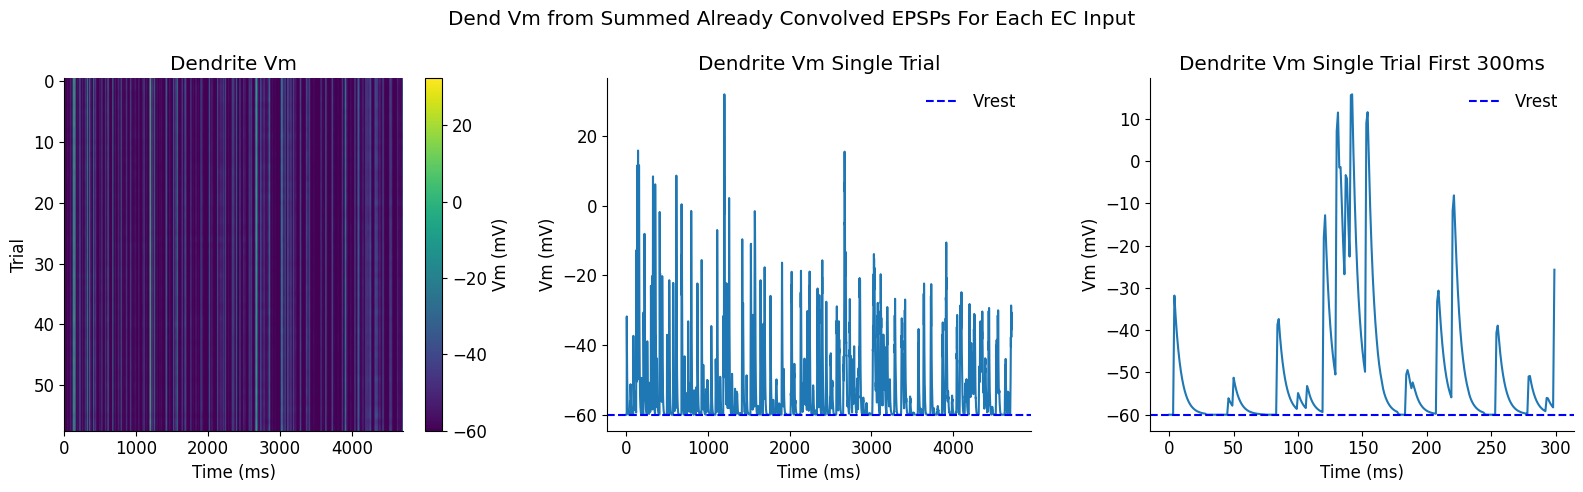

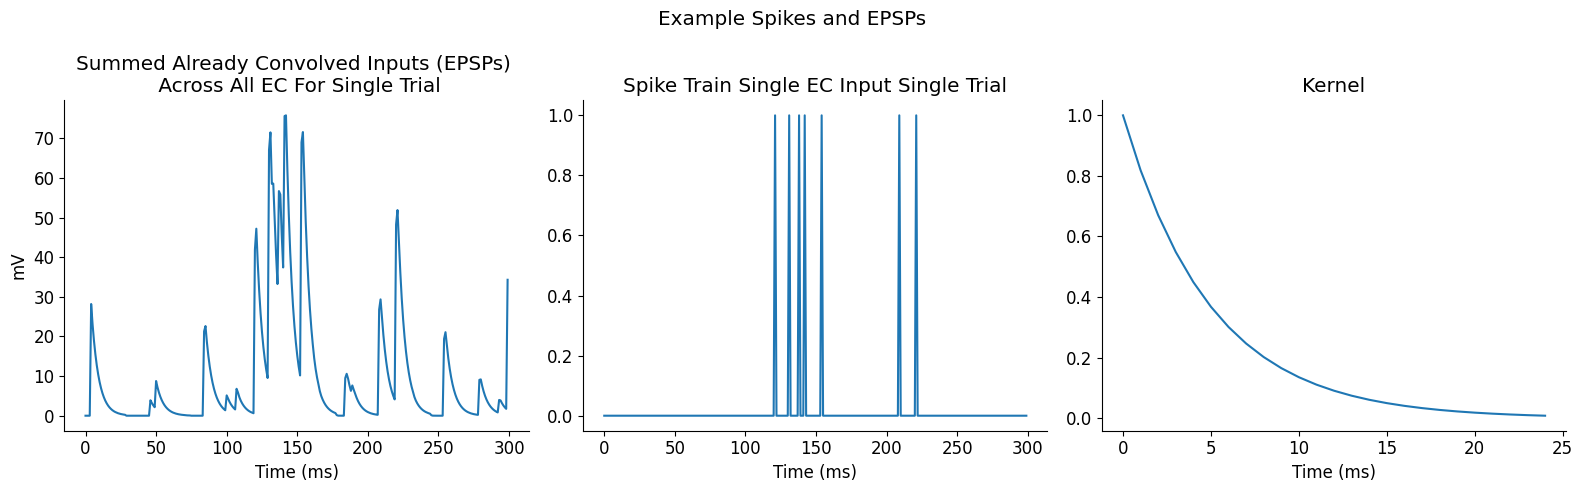

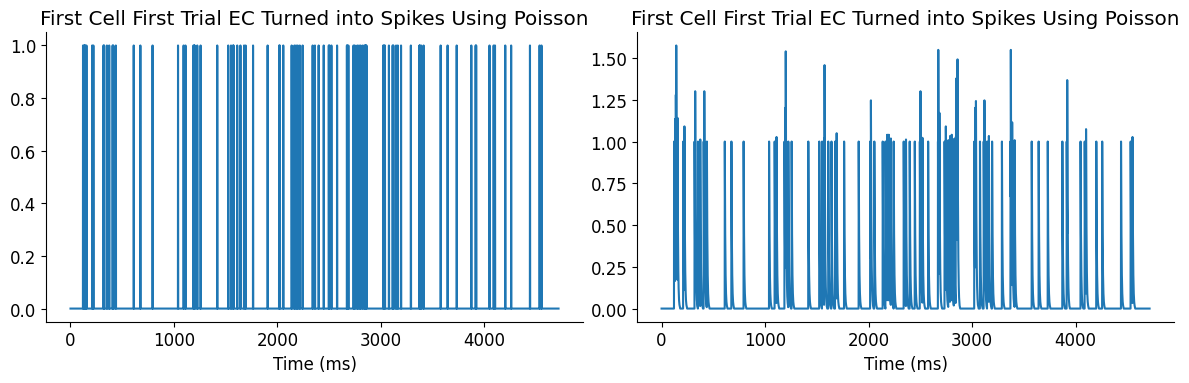

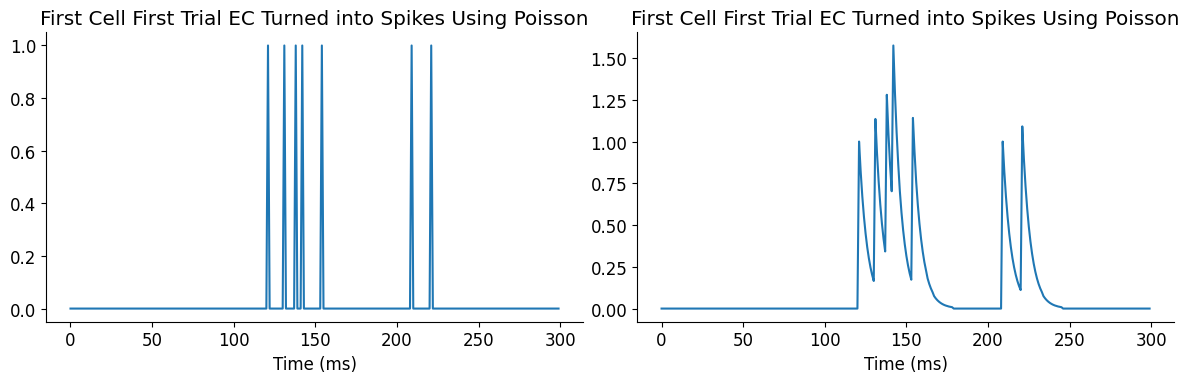

In [ ]:
epsp_list = []
spike_list = []

for animal in animal_dict:
    for cell in animal_dict[animal]:
        epsp = animal_dict[animal][cell]["epsps"]
        epsp_list.append(epsp)
        spike_train = animal_dict[animal][cell]["spike_train"]
        spike_list.append(spike_train)

epsp_array = np.array(epsp_list)

epsp_sf = 0.1

sum_epsp = np.sum(epsp_array, axis=0)*epsp_sf

Vrest = -60

dend_Vm = sum_epsp + Vrest


fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Dend Vm from Summed Already Convolved EPSPs For Each EC Input")

axs[2].plot(dend_Vm[0,:300])
axs[2].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[2].legend()
axs[2].set_title("Dendrite Vm Single Trial First 300ms")
axs[2].set_ylabel("Vm (mV)")
axs[2].set_xlabel("Time (ms)")


axs[1].plot(dend_Vm[0,:])
axs[1].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[1].legend()
axs[1].set_title("Dendrite Vm Single Trial")
axs[1].set_ylabel("Vm (mV)")
axs[1].set_xlabel("Time (ms)")

im = axs[0].imshow(dend_Vm, aspect='auto')
axs[0].set_title("Dendrite Vm")
axs[0].set_ylabel("Trial")
axs[0].set_xlabel("Time (ms)")
fig.colorbar(im, ax=axs[0], label='Vm (mV)')

plt.tight_layout()
plt.plot()

fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Example Spikes and EPSPs")

example_spike_data = animal_dict["animal_1"]["cell_1"]["spike_train"][0,:]
# example_summed_epsp = sum_epsp[0]

axs[1].plot(example_spike_data[:300])
axs[1].set_title("Spike Train Single EC Input Single Trial")
# axs[1].set_ylabel("Vm (mV)")
axs[1].set_xlabel("Time (ms)")

axs[0].plot(sum_epsp[0,:300])
axs[0].set_title("Summed Already Convolved Inputs (EPSPs) \n Across All EC For Single Trial")
axs[0].set_ylabel("mV")
axs[0].set_xlabel("Time (ms)")

dt_ms = dt_constant * 1000.0      # 1 ms

tau_ms  = 5.0
dt_ms   = dt_constant * 1000.0      # 1 ms
AMP     = 1                       # mV
MODE    = "peak"                    # "area" or "peak"
kernel  = exp_kernel(tau_ms, dt_ms, n_taus=5, norm=MODE, target=AMP)

axs[2].plot(kernel)
axs[2].set_title("Kernel")
# ax[1].set_ylabel("Vm (mV)")
axs[2].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(spike_list[0][0,:])
axs[0].set_title("First Cell First Trial EC Turned into Spikes Using Poisson")
axs[0].set_xlabel("Time (ms)")

axs[1].plot(epsp_list[0][0,:])
axs[1].set_title("First Cell First Trial EC Turned into Spikes Using Poisson")
axs[1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(spike_list[0][0,:300])
axs[0].set_title("First Cell First Trial EC Turned into Spikes Using Poisson")
axs[0].set_xlabel("Time (ms)")

axs[1].plot(epsp_list[0][0,:300])
axs[1].set_title("First Cell First Trial EC Turned into Spikes Using Poisson")
axs[1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

input_spikes_for_dendrite.shape (58, 4921)
dendrite.shape (58, 4921)


[]

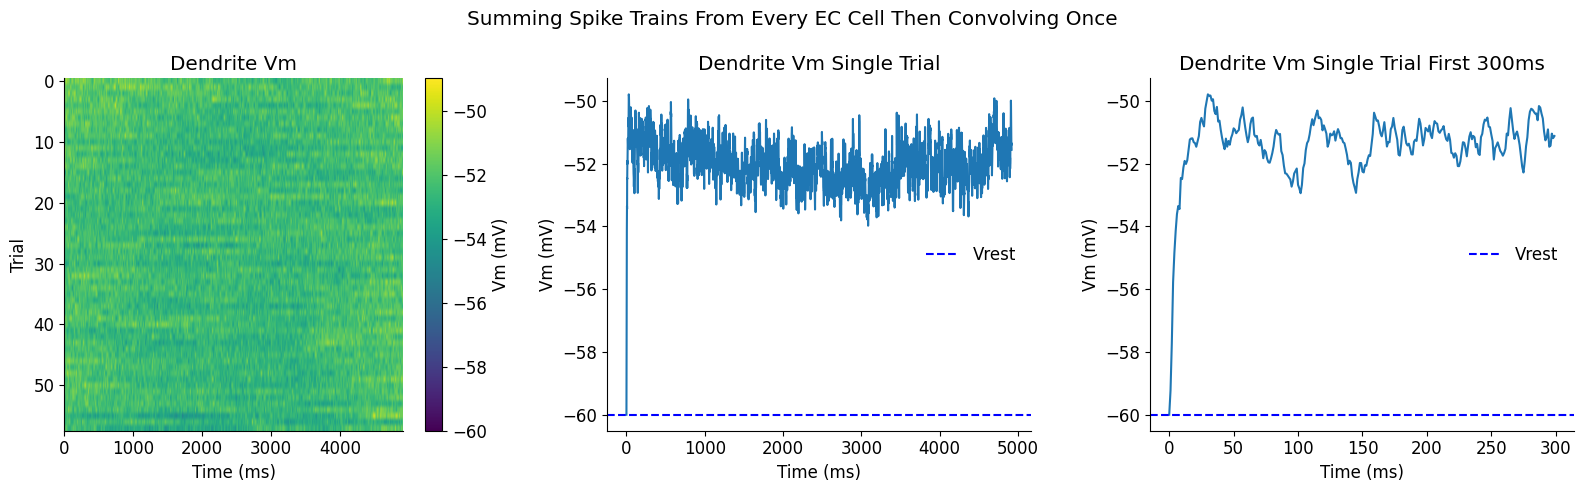

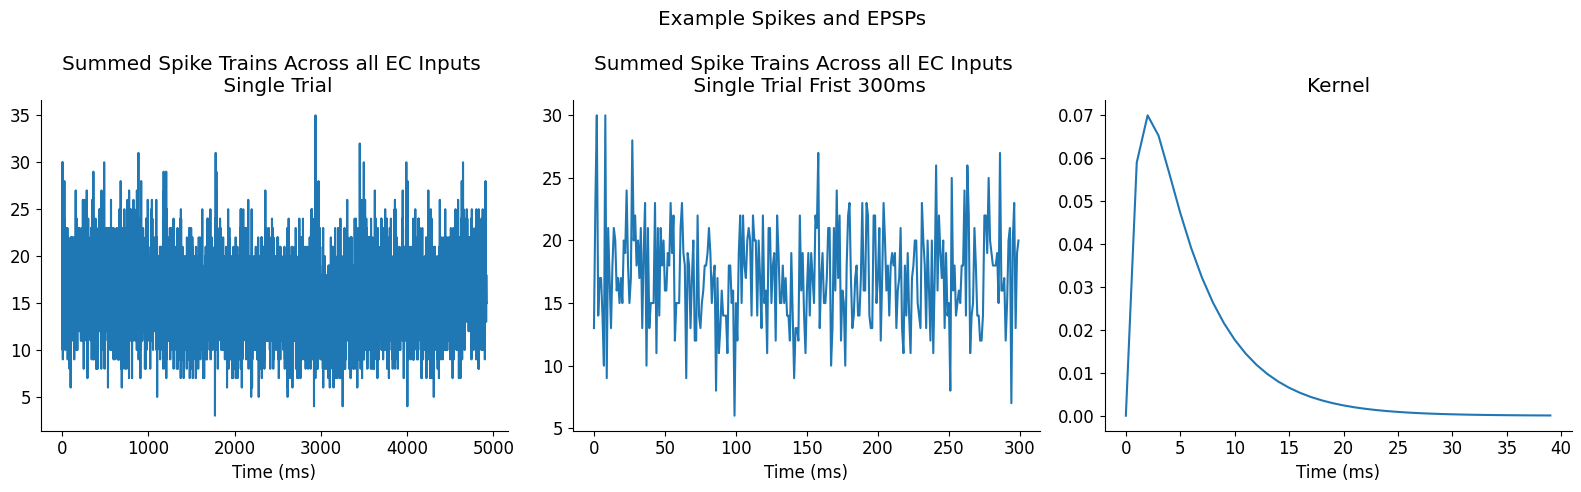

In [ ]:
spike_all_cells_list = []

for animal in epsp_dict:
    for cell in epsp_dict[animal]:
        spk = epsp_dict[animal][cell]["spike_train"]
        seqs = [spk[k] for k in sorted(spk)]
        array_trains = pad_sequences(seqs, pad_value=np.nan, dtype=float)
        spike_all_cells_list.append(array_trains)

spike_all_cells_array = np.array(spike_all_cells_list)

input_spikes_for_dendrite = np.nansum(spike_all_cells_array, axis=0) #### sum spike trains across all 800 EC cells 

print(f"input_spikes_for_dendrite.shape {input_spikes_for_dendrite.shape}")

Vrest   = -60.0
dt      = 1.0     # ms per bin (adjust to match your spike train bin size!)
tau_r   = 1.     # ms rise
tau_d   = 5.0     # ms decay
A       = 0.07     # mV per input spike (scale this down if many inputs)

# --- build EPSP kernel (double exponential) ---
tmax   = int(np.ceil(8 * tau_d / dt))
tvec   = np.arange(tmax) * dt
kernel = np.exp(-tvec / tau_d) - np.exp(-tvec / tau_r)
kernel /= kernel.max()   # normalize peak to 1
kernel *= A              # scale amplitude

# --- input_spikes_for_dendrite: shape (n_trials, T) ---
# convolve each trial’s summed spike rate with EPSP kernel
Vm_trials = []
for trial in range(input_spikes_for_dendrite.shape[0]):
    spikes = input_spikes_for_dendrite[trial, :]   # summed spike counts this trial
    epsp   = np.convolve(spikes, kernel, mode="full")[:spikes.shape[0]]
    Vm     = Vrest + epsp
    Vm_trials.append(Vm)

dendrite = np.array(Vm_trials)  # shape (n_trials, T)


print(f"dendrite.shape {dendrite.shape}")


fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Summing Spike Trains From Every EC Cell Then Convolving Once")

axs[2].plot(dendrite[0][:300])
axs[2].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[2].legend()
axs[2].set_title("Dendrite Vm Single Trial First 300ms")
axs[2].set_ylabel("Vm (mV)")
axs[2].set_xlabel("Time (ms)")

axs[1].plot(dendrite[0])
axs[1].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[1].legend()
axs[1].set_title("Dendrite Vm Single Trial")
axs[1].set_ylabel("Vm (mV)")
axs[1].set_xlabel("Time (ms)")

im = axs[0].imshow(dendrite, aspect='auto')
axs[0].set_title("Dendrite Vm")
axs[0].set_ylabel("Trial")
axs[0].set_xlabel("Time (ms)")
fig.colorbar(im, ax=axs[0], label='Vm (mV)')

plt.tight_layout()
plt.plot()




fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Example Spikes and EPSPs")

example_spike_data = epsp_dict["animal_1"]["cell_1"]["spike_train"][0]
# example_summed_epsp = sum_epsp[0]

axs[2].plot(kernel)
axs[2].set_title("Kernel")
axs[2].set_xlabel("Time (ms)")

axs[1].plot(input_spikes_for_dendrite[0,:300])
axs[1].set_title("Summed Spike Trains Across all EC Inputs \n Single Trial Frist 300ms")
axs[1].set_xlabel("Time (ms)")

axs[0].plot(input_spikes_for_dendrite[0,:])
axs[0].set_title("Summed Spike Trains Across all EC Inputs \n Single Trial")
axs[0].set_xlabel("Time (ms)")


plt.tight_layout()
plt.plot()



# Vrest = -60.0
# tau=5.0

# input_spikes_for_dendrite_ex = input_spikes_for_dendrite[0,:]
# T = len(input_spikes_for_dendrite_ex)


# Vm = np.zeros(T)
# Vm[0] = Vrest

# for t in range(1,T):
#      Vm[t+1] = Vm[t] + ((-Vm[t] + input_spikes_for_dendrite_ex[t]) / tau)
#     #  if input_spikes_for_dendrite[t] == 1:
#     #     Vm[t] += epsp_amp 

# plt.plot(Vm)


[]

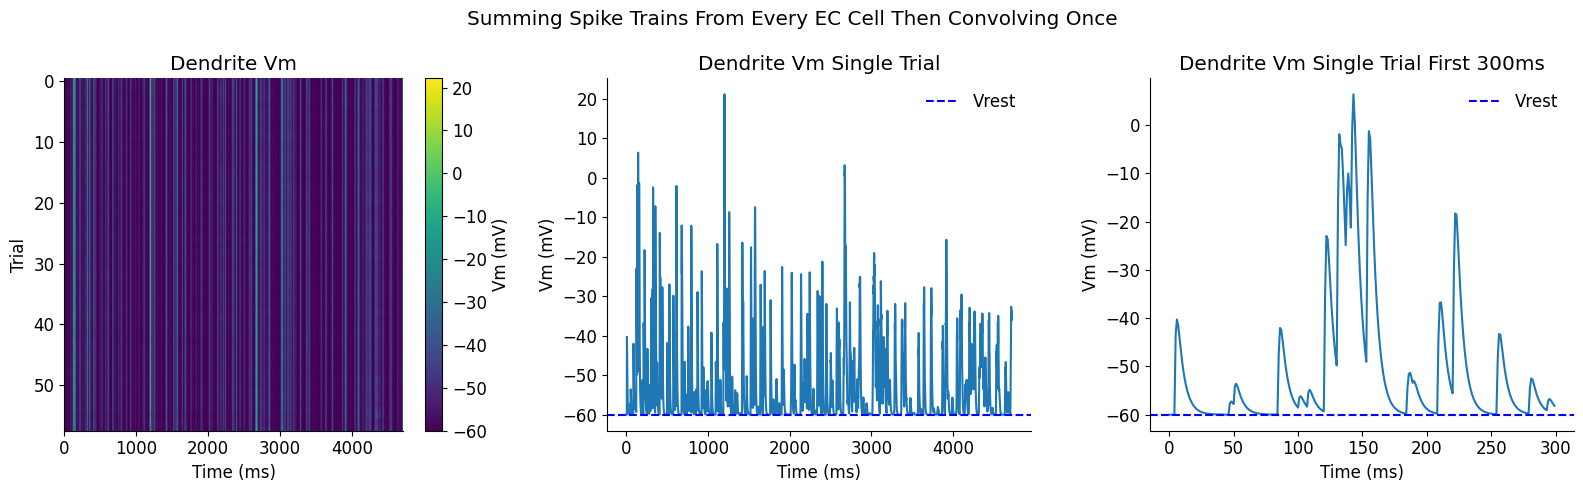

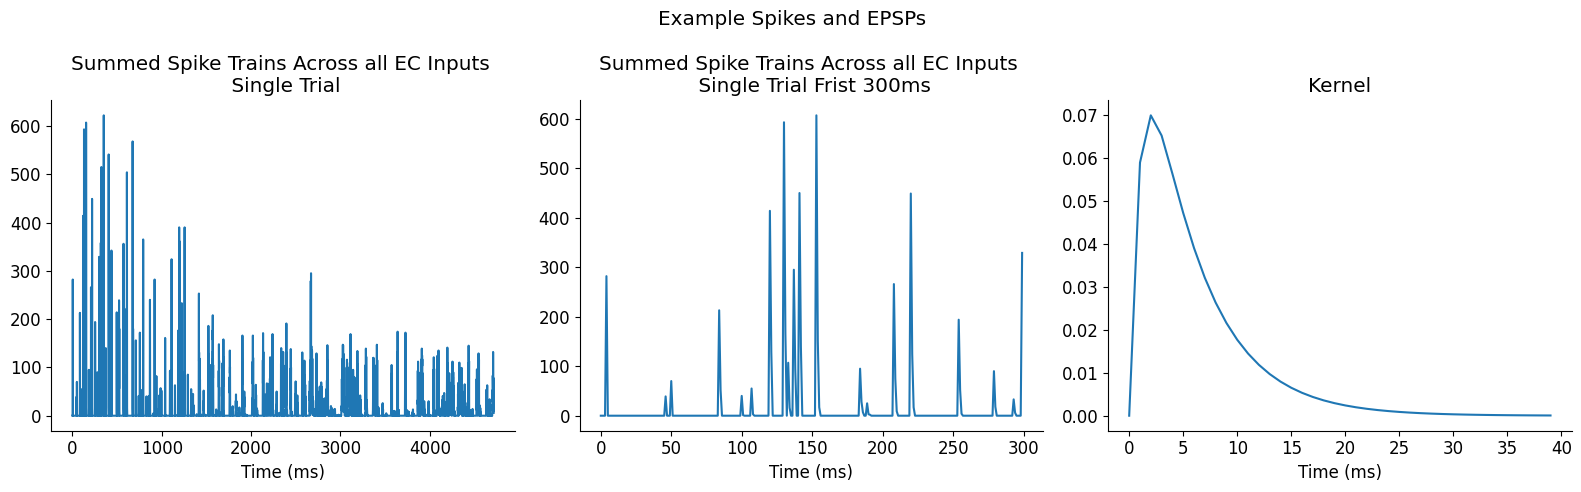

In [ ]:
spike_all_cells_list = []

for animal in epsp_dict:
    for cell in epsp_dict[animal]:
        spike_data = epsp_dict[animal][cell]["spike_train"]
        spike_all_cells_list.append(spike_data)

spike_all_cells_array = np.array(spike_all_cells_list)

input_spikes_for_dendrite = np.sum(spike_all_cells_array, axis=0) #### sum spike trains across all 800 EC cells 

Vrest   = -60.0
dt      = 1.0     # ms per bin (adjust to match your spike train bin size!)
tau_r   = 1.     # ms rise
tau_d   = 5.0     # ms decay
A       = 0.07     # mV per input spike (scale this down if many inputs)

# --- build EPSP kernel (double exponential) ---
tmax   = int(np.ceil(8 * tau_d / dt))
tvec   = np.arange(tmax) * dt
kernel = np.exp(-tvec / tau_d) - np.exp(-tvec / tau_r)
kernel /= kernel.max()   # normalize peak to 1
kernel *= A              # scale amplitude

# --- input_spikes_for_dendrite: shape (n_trials, T) ---
# convolve each trial’s summed spike rate with EPSP kernel
Vm_trials = []
for trial in range(input_spikes_for_dendrite.shape[0]):
    spikes = input_spikes_for_dendrite[trial, :]   # summed spike counts this trial
    epsp   = np.convolve(spikes, kernel, mode="full")[:spikes.shape[0]]
    Vm     = Vrest + epsp
    Vm_trials.append(Vm)

dendrite = np.array(Vm_trials)  # shape (n_trials, T)




fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Summing Spike Trains From Every EC Cell Then Convolving Once")

axs[2].plot(dendrite[0][:300])
axs[2].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[2].legend()
axs[2].set_title("Dendrite Vm Single Trial First 300ms")
axs[2].set_ylabel("Vm (mV)")
axs[2].set_xlabel("Time (ms)")

axs[1].plot(dendrite[0])
axs[1].axhline(Vrest, color='b', linestyle='--', label="Vrest")
axs[1].legend()
axs[1].set_title("Dendrite Vm Single Trial")
axs[1].set_ylabel("Vm (mV)")
axs[1].set_xlabel("Time (ms)")

im = axs[0].imshow(dendrite, aspect='auto')
axs[0].set_title("Dendrite Vm")
axs[0].set_ylabel("Trial")
axs[0].set_xlabel("Time (ms)")
fig.colorbar(im, ax=axs[0], label='Vm (mV)')

plt.tight_layout()
plt.plot()




fig, axs= plt.subplots(1,3, figsize=(16,5))

fig.suptitle("Example Spikes and EPSPs")

example_spike_data = animal_dict["animal_1"]["cell_1"]["spike_train"][0,:]
# example_summed_epsp = sum_epsp[0]

axs[2].plot(kernel)
axs[2].set_title("Kernel")
axs[2].set_xlabel("Time (ms)")

axs[1].plot(input_spikes_for_dendrite[0,:300])
axs[1].set_title("Summed Spike Trains Across all EC Inputs \n Single Trial Frist 300ms")
axs[1].set_xlabel("Time (ms)")

axs[0].plot(input_spikes_for_dendrite[0,:])
axs[0].set_title("Summed Spike Trains Across all EC Inputs \n Single Trial")
axs[0].set_xlabel("Time (ms)")


plt.tight_layout()
plt.plot()



# Vrest = -60.0
# tau=5.0

# input_spikes_for_dendrite_ex = input_spikes_for_dendrite[0,:]
# T = len(input_spikes_for_dendrite_ex)


# Vm = np.zeros(T)
# Vm[0] = Vrest

# for t in range(1,T):
#      Vm[t+1] = Vm[t] + ((-Vm[t] + input_spikes_for_dendrite_ex[t]) / tau)
#     #  if input_spikes_for_dendrite[t] == 1:
#     #     Vm[t] += epsp_amp 

# plt.plot(Vm)
